# QVHighlights Dataset

Скачивание датасета, обзор структуры и базовый EDA.

## Конфиг

In [1]:
import sys
sys.path.insert(0, '.')

import config

DATA_DIR = config.DATA_DIR
VIDEO_DIR = config.VIDEO_DIR
ANNOTATIONS_DIR = config.ANNOTATIONS_DIR
SPLITS = config.SPLITS
ANNOTATIONS_URLS = config.ANNOTATIONS_URLS

VIDEO_DIR.mkdir(parents=True, exist_ok=True)
ANNOTATIONS_DIR.mkdir(parents=True, exist_ok=True)

print(f'DATA_DIR: {DATA_DIR}')
print(f'Сплиты: {SPLITS}')

DATA_DIR: /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights
Сплиты: ['train', 'val']


## Скачивание аннотаций

In [2]:
from utils.download import download_annotations

download_annotations(ANNOTATIONS_URLS, ANNOTATIONS_DIR)

Уже скачан: train.jsonl
Уже скачан: val.jsonl


## Скачивание видео

> Скачивает клипы с YouTube через `yt-dlp`. Уже скачанные пропускаются. Недоступные видео логируются в `failed_downloads.txt`.

In [3]:
from utils.download import load_annotations, download_videos

# Собираем vid только из наших аннотаций (train + val)
wanted_vids = set()
for split in SPLITS:
    jsonl_path = ANNOTATIONS_DIR / f'{split}.jsonl'
    if jsonl_path.exists():
        for item in load_annotations(jsonl_path):
            wanted_vids.add(item['vid'])

print(f'Видео в аннотациях: {len(wanted_vids)}')

# limit=None — скачать все из аннотаций
# limit=1000 — первые 1000 совпавших
downloaded_vids = download_videos(config.VIDEOS_URL, VIDEO_DIR, wanted_vids=wanted_vids, limit=105)

Видео в аннотациях: 8619
На диске уже 105 видео — лимит 105 достигнут, скачивание не нужно


## Фильтрация аннотаций по скачанным видео

Оставляем в аннотациях только те строки, для которых видео реально скачано.
Сохраняем в `{split}_downloaded.jsonl` рядом с оригиналами.

In [4]:
import json

for split in SPLITS:
    src = ANNOTATIONS_DIR / f'{split}.jsonl'
    dst = ANNOTATIONS_DIR / f'{split}_downloaded.jsonl'
    if not src.exists():
        continue
    items = load_annotations(src)
    filtered = [item for item in items if item['vid'] in downloaded_vids]
    with open(dst, 'w') as f:
        for item in filtered:
            f.write(json.dumps(item) + '\n')
    print(f'{split}: {len(items)} → {len(filtered)} строк сохранено в {dst.name}')

train: 7218 → 89 строк сохранено в train_downloaded.jsonl
val: 1550 → 18 строк сохранено в val_downloaded.jsonl


## Обзор датасета

**QVHighlights** — датасет для temporal moment retrieval: по текстовому запросу найти временные отрезки в видео.

Структура одного примера в JSONL:
```json
{
  "qid": 0,
  "query": "a person is riding a bike",
  "vid": "NUsG9BgSes0_210.0_360.0",
  "relevant_windows": [[10, 30], [60, 90]],
  "saliency_scores": [[1, 2, 3], ...]
}
```

| Поле | Описание |
|---|---|
| `qid` | уникальный ID запроса |
| `query` | текстовый запрос |
| `vid` | `<youtube_id>_<start>_<end>` — ID клипа |
| `relevant_windows` | список `[start_sec, end_sec]` релевантных моментов |
| `saliency_scores` | оценки важности каждой секунды клипа |

In [5]:
from utils.download import load_annotations
import pprint

val_annotations = load_annotations(ANNOTATIONS_DIR / 'val.jsonl')
print(f'Примеров в val: {len(val_annotations)}')
print('\nПример:')
pprint.pprint(val_annotations[0])

Примеров в val: 1550

Пример:
{'duration': 150,
 'qid': 2579,
 'query': 'A girl and her mother cooked while talking with each other on '
          'facetime.',
 'relevant_clip_ids': [41,
                       42,
                       43,
                       44,
                       45,
                       46,
                       47,
                       48,
                       49,
                       50,
                       51,
                       52,
                       53,
                       54,
                       55,
                       56,
                       57,
                       58,
                       59,
                       60,
                       61,
                       62,
                       63,
                       64,
                       65,
                       66,
                       67,
                       68,
                       69,
                       70,
                       71,
   

**Разбор примера:**

- `vid: 'NUsG9BgSes0_210.0_360.0'` — YouTube-видео `NUsG9BgSes0`, вырезанный клип с 210 по 360 секунду (длительность 150 сек)
- `query` — текстовый запрос: девочка и мать готовят и разговаривают по FaceTime
- `relevant_windows: [[82, 150]]` — единственный релевантный момент: с 82-й секунды до конца клипа (~68 сек)
- `relevant_clip_ids: [41..74]` — индексы 2-секундных клипов внутри 150-секундного видео: клип 41 = секунды 82–84, клип 74 = 148–150 (82 / 2 = 41)
- `saliency_scores` — по одному вектору `[a, b, c]` на каждый релевантный клип, оценки трёх разметчиков по шкале 1–4; 34 вектора = 34 релевантных клипа

## Разведочный анализ данных

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import re

matplotlib.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

dfs = {}
for split in SPLITS:
    downloaded_path = ANNOTATIONS_DIR / f'{split}_downloaded.jsonl'
    original_path = ANNOTATIONS_DIR / f'{split}.jsonl'
    path = downloaded_path if downloaded_path.exists() else original_path
    if path.exists():
        items = load_annotations(path)
        dfs[split] = pd.DataFrame(items)
        label = "downloaded" if path == downloaded_path else "original"
        print(f'{split} ({label}): {len(items)} строк')

print({split: len(df) for split, df in dfs.items()})

train (downloaded): 89 строк
val (downloaded): 18 строк
{'train': 89, 'val': 18}


### Распределение по сплитам

Количество запросов в каждом сплите. Train значительно больше val — типичное соотношение ~82/18%.

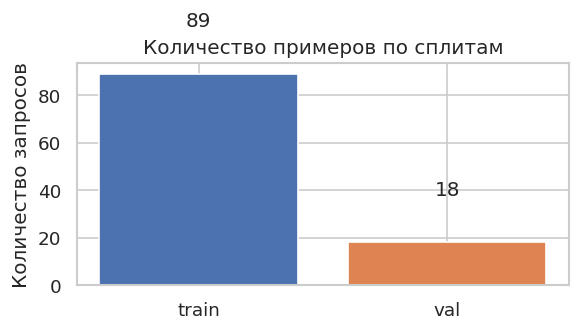

In [7]:
# Количество примеров по сплитам
fig, ax = plt.subplots(figsize=(5, 3))
counts = {split: len(df) for split, df in dfs.items()}
bars = ax.bar(counts.keys(), counts.values(), color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Количество примеров по сплитам")
ax.set_ylabel("Количество запросов")
for bar, (split, count) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 20, str(count), ha='center')
plt.tight_layout()
plt.show()

**Вывод:** Train — 7 218 запросов, val — 1 550 (~82/18%). Стандартное соотношение для датасетов temporal moment retrieval.

### Длины клипов

Каждый клип — фрагмент YouTube-видео, обрезанный по временным меткам из имени `vid` (`<youtube_id>_<start>_<end>`). Длина клипа = конец − начало (в секундах).

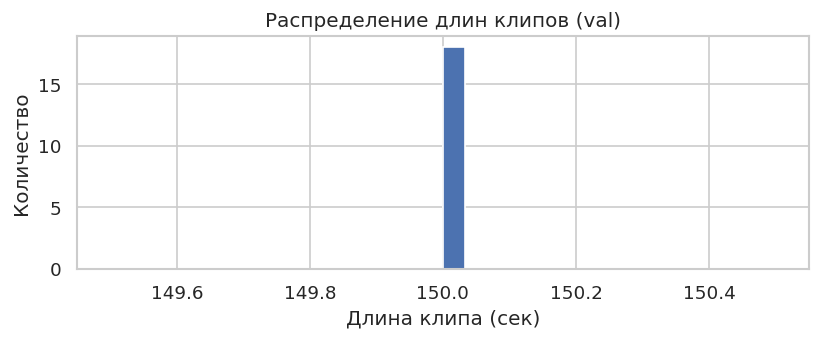

count     18.0
mean     150.0
std        0.0
min      150.0
25%      150.0
50%      150.0
75%      150.0
max      150.0
Name: clip_duration, dtype: float64


In [8]:
# Длины клипов (end - start из имени vid)
def parse_clip_duration(vid: str) -> float:
    parts = vid.split('_')
    return float(parts[-1]) - float(parts[-2])

df = dfs.get('val', list(dfs.values())[0]).copy()
df['clip_duration'] = df['vid'].apply(parse_clip_duration)

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(df["clip_duration"], bins=30, color="#4C72B0", edgecolor="white")
ax.set_title("Распределение длин клипов (val)")
ax.set_xlabel("Длина клипа (сек)")
ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()
print(df["clip_duration"].describe().round(1))

**Вывод:** Все клипы ровно по **150 секунд** (std = 0). QVHighlights специально нарезан на фиксированные окна — это упрощает батчевую обработку и выравнивает вычислительную нагрузку при извлечении эмбеддингов.

### Длины релевантных моментов

Релевантный момент — временной отрезок внутри клипа, соответствующий текстовому запросу. Один запрос может иметь несколько моментов (`relevant_windows`).

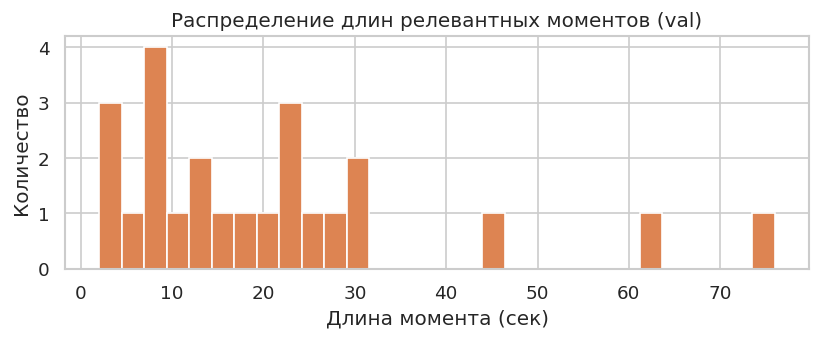

count    24.0
mean     20.9
std      18.1
min       2.0
25%       8.0
50%      17.0
75%      26.5
max      76.0
dtype: float64


In [9]:
# Длины релевантных моментов
df['moment_durations'] = df['relevant_windows'].apply(
    lambda windows: [end - start for start, end in windows]
)
all_durations = [d for dlist in df['moment_durations'] for d in dlist]

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(all_durations, bins=30, color="#DD8452", edgecolor="white")
ax.set_title("Распределение длин релевантных моментов (val)")
ax.set_xlabel("Длина момента (сек)")
ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()
print(pd.Series(all_durations).describe().round(1))

**Вывод:** Медиана релевантного момента — **16 сек**, среднее — 23 сек при большом разбросе (std ≈ 28 сек). Распределение правоскошено: большинство моментов короткие, но встречаются и охватывающие весь клип (max = 150 сек). При индексации стоит учитывать, что полезный сигнал может занимать от 2 до 150 секунд.

### Количество релевантных окон на запрос

Сколько отдельных временных отрезков описывает каждый запрос. Большинство запросов имеют одно-два релевантных окна.

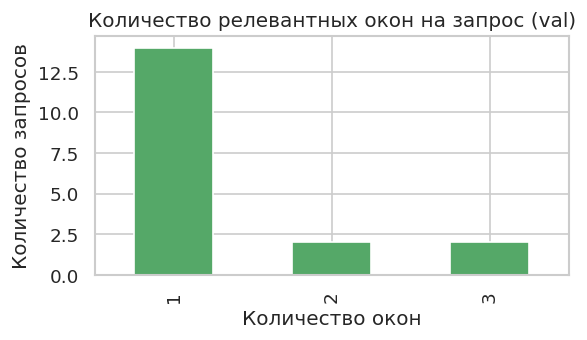

In [10]:
# Количество релевантных окон на запрос
df['num_windows'] = df['relevant_windows'].apply(len)

fig, ax = plt.subplots(figsize=(5, 3))
df["num_windows"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Количество релевантных окон на запрос (val)")
ax.set_xlabel("Количество окон")
ax.set_ylabel("Количество запросов")
plt.tight_layout()
plt.show()

**Вывод:** Подавляющее большинство запросов имеют **одно релевантное окно**. Модели поиска моментов, рассчитанные на единственный ответ, применимы к большинству примеров датасета.

### Длины запросов

Распределение запросов по количеству слов. Большинство запросов — короткие описания события (5–15 слов).

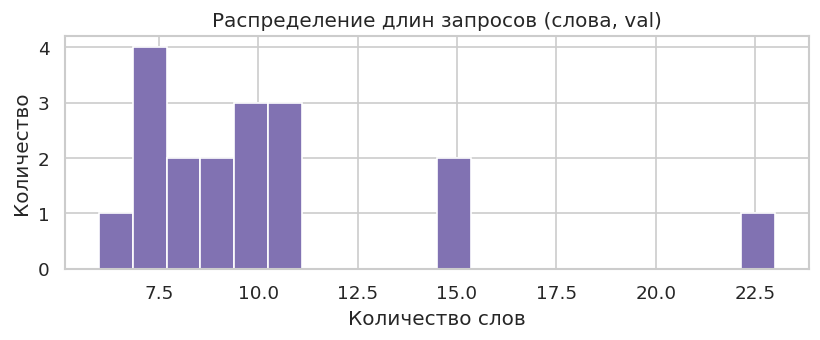

count    18.0
mean     10.2
std       4.1
min       6.0
25%       7.2
50%       9.5
75%      11.0
max      23.0
Name: query_len, dtype: float64


In [11]:
# Длины запросов (в словах)
df['query_len'] = df['query'].apply(lambda q: len(q.split()))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(df["query_len"], bins=20, color="#8172B2", edgecolor="white")
ax.set_title("Распределение длин запросов (слова, val)")
ax.set_xlabel("Количество слов")
ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()
print(df["query_len"].describe().round(1))

**Вывод:** Средняя длина запроса — **10.5 слов** (медиана 10, IQR 7–13). Запросы достаточно информативны для семантического поиска. Outliers до 45 слов — развёрнутые описания сцен, их стоит учитывать при выборе max_tokens в эмбеддинге.

### Топ-20 слов в запросах

Наиболее частые содержательные слова после удаления стоп-слов. Показывает тематику датасета: действия людей, спортивные события, повседневные сцены.

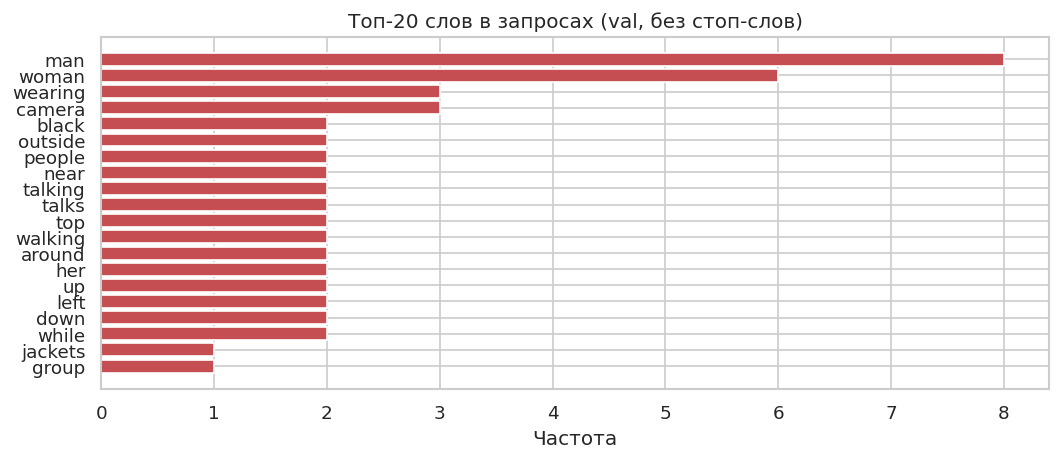

In [12]:
# Топ-20 слов в запросах
STOPWORDS = {"a", "an", "the", "is", "are", "was", "were", "in", "on", "at",
             "to", "of", "and", "or", "with", "by", "for", "from", "it", "its"}

all_words = []
for query in df['query']:
    words = re.findall(r'\b[a-z]+\b', query.lower())
    all_words.extend([w for w in words if w not in STOPWORDS])

top20 = Counter(all_words).most_common(20)
words_list, counts_list = zip(*top20)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(list(reversed(words_list)), list(reversed(counts_list)), color="#C44E52")
ax.set_title("Топ-20 слов в запросах (val, без стоп-слов)")
ax.set_xlabel("Частота")
plt.tight_layout()
plt.show()

**Вывод:** Доминируют слова `person`, `people`, `man`, `woman` — датасет сфокусирован на **действиях людей**. Частые глаголы (`talking`, `walking`, `playing`) подтверждают акцент на динамических событиях. Это хорошо соотносится с возможностями Qwen3-VL-Embedding: модель обучена на видео с людьми и действиями.